# International Football Prediction — Research Record

This notebook records the project's data preparation, feature
experiments, chronological model comparisons, calibration,
historical evaluation, and deployment preparation.

Saved tables and figures document completed experiments. This notebook
is a research record, not a guaranteed top-to-bottom execution workflow
from a fresh clone.

## Local checkpoint dependencies

Some sections load historical model and experiment snapshots from
`checkpoints/`. These local files are not included in the repository.
Sections labeled **Local checkpoint required** cannot run without
the specified files.

These sections preserve the project's debugging, correction, and
artifact-preparation history. They are not required to use the app.

## Run the application

The application loads the included deployment files:

- `artifacts/model_bundle.joblib`
- `artifacts/latest_team_state.joblib`

Follow the setup instructions in `README.md`. Running the Flask app
does not require executing this notebook.

## Evaluation scope

Reported historical metrics describe the evaluated historical model.
The deployment model was refitted using newer data and does not inherit
an independent test score from that historical evaluation.

In [2]:
##LOAD DATA
import pandas as pd
import numpy as np
import collections
import math
from collections import deque
from sklearn.preprocessing import LabelEncoder #label into number
from sklearn.metrics import classification_report, log_loss # evaluation, calculates precision, f1, etc and measures quality of predicted prob.
from xgboost import XGBClassifier #ML model, XGBoost, tree based model, often a hard, axis-aligned binary split
from sklearn.model_selection import GridSearchCV #hyperparameter tuning
from sklearn.utils.class_weight import compute_sample_weight 
import joblib #saving best_model
import os #accessing saved best_model via os
from pathlib import Path

# Load the local data
df = pd.read_csv('results.csv')
# Look at the first 5 rows
df.head()


# Pipeline: 
# 1. load data + define prediction target (win/draw/loss) 
# 2. Clean and inspect results 
# 3. Build pre-match features 
# 4. Establish chronlogical evaluation (development, calibration, selection, holdout) 
# 5. Compare feature features and models 
# 6. Tune and calibrate (fitted fianlist models)
# 7. Select and evaluate (chose LR sigmoid) 
# 8. Verify reproducibility (replay consistency) + corrected checkpoint) 
# 9. package prediction inference (predict_match) + save model to disk (joblib.dump) + load model from disk (joblib.load) + plot feature importance (matplotlib)
# 10. Prepare deployment artifacts (more recent fitting utilizing separate calibration data)
# 11. Build Flask interface (frontend) to run prediction model (predict_match) 
# 12. Document and deploy (README, requirements.txt, etc)
# 13. Track future prediction 
# 14. Develop version 2 (implementing more features)
# 15. Extend to tournmanet simulator


#used later for cmd path
PROJECT_ROOT = Path.cwd()

assert (PROJECT_ROOT / "results.csv").is_file(), (
    "Start Jupyter from the world_cup_ml project folder."
)

CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"

# Obsolete pipeline:
#steps: 1. load data and organize/categorize it in readible manner 
# 2. Add features to it such as win (H for home win, A for away win, etc) for classifying
# 3. Iterate through all the rows in df (matches) and calculate elo accordingly (along with rolling form) = feature engineering
# 4. Utilize input values created from feature engineering to run ML model to create output (train it using training data) / chronological and split model training
# 5. ^ doing various ways to prevent omitting draws (such as rolling goal avg, sample weights, etc) = training model
# 6. utilizing gridsearchcv to find best parameters based on scoring (f1_weighted, precision, etc), which
# led the model to prevent predicting 0% draw guess -> create a function (predict_match that can apply the model
# to actual prediction between two teams, also use matplotlib to plot_importance (of features), and save model
# to disk via joblib.dump (dump the best_model variable, such the ml model)
# 7. after best model obtained, run P(Home / Draw / Away), prediction model

# potential next step improvement process: current XGBoost -> improve feature engineering -> fix draw/class imbalance
# -> time-based validation -> hyperparameter tuning -> compare models -> probability calibration -> final evaluation on 2022+ test set

# sample weights, penalizing it for getting draw wrong more than getting home wrong
# optimizing sample weight (draw weight = x) and try different values to evaluate systematically is a professional step
# ^ systematically meaning validation data / cross-validation < - finding vest validation log loss value?

# feature engineering candidates to improve model: recent team performance (rolling goal avg?), 
# elo rating of each team rather than difference, FIFA ranking, head-to-head history, etc


# data -> feature eng -> compare models -> decide on lr (tuned) w/ ensemble (w/ 
# xgboost + lightgbm) -> ensemble -> calibration -> calibrated log loss value





In [17]:
## ORGANIZE DATA
print(f"Total raw matches in history: {df.shape[0]}\n") #size of data

print("Top 15 most common tournament types:") 
print(df['tournament'].value_counts().head(15)) #print 15 most common tournament types ('tournament')
print("\n" + "="*50 + "\n")

df_competitive = df[df['tournament'] != 'Friendly'].copy() # filter out 'Friendly' matches

print(f"Total competitive matches left: {df_competitive.shape[0]}")
print(f"Removed {df.shape[0] - df_competitive.shape[0]} friendly matches.\n")

print("First 5 rows of competitive matches:")
display(df_competitive.head())

df_competitive.to_csv('results_cleaned.csv', index=False) #new file for usable data
print("\nSaved clean data to 'results_cleaned.csv'!")


Total raw matches in history: 49493

Top 15 most common tournament types:
tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1052
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Name: count, dtype: int64


Total competitive matches left: 31105
Removed 18388 friendly matches.

First 5 rows of competitive matches:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
29,1884-01-26,Northern Ireland,Scotland,0.0,5.0,British Home Championship,Belfast,Ireland,False
30,1884-02-09,Wales,Northern Ireland,6.0,0.0,British Home Championship,Wrexham,Wales,False
31,1884-02-23,Northern Ireland,England,1.0,8.0,British Home Championship,Belfast,Ireland,False
32,1884-03-15,Scotland,England,1.0,0.0,British Home Championship,Glasgow,Scotland,False
33,1884-03-17,Wales,England,0.0,4.0,British Home Championship,Wrexham,Wales,False



Saved clean data to 'results_cleaned.csv'!


In [18]:
## ORGANIZE DATA

df = pd.read_csv('results_cleaned.csv')

df['date'] = pd.to_datetime(df['date']) 

df['goal_difference'] = df['home_score'] - df['away_score'] # goal difference column

def determine_outcome(goal_diff):
    if goal_diff > 0:
        return 'H' #home
    elif goal_diff < 0:
        return 'A' #away
    else: 
        return 'D' #draw

#formula determining who won each row
df['match_outcome'] = df['goal_difference'].apply(determine_outcome) 

#checking whether the match is actually played at host country
df['is_home_team_host'] = (df['home_team'] == df['country']) & (~df['neutral'])

print("Distribution of match outcomes:")
print(df['match_outcome'].value_counts(normalize=True) * 100)
print("\n" + "="*50 + "\n")

print("First 5 rows with our newly engineered features:")
display(df[['date', 'home_team', 'away_team', 'goal_difference', 'match_outcome', 'is_home_team_host']].head())

df.to_csv('results_features.csv', index=False)

print("\nSuccess, adding eng features, saved to 'results_features.csv'") 


Distribution of match outcomes:
match_outcome
H    49.975888
A    28.651342
D    21.372770
Name: proportion, dtype: float64


First 5 rows with our newly engineered features:


,date,home_team,away_team,goal_difference,match_outcome,is_home_team_host
0,1884-01-26,Northern Ireland,Scotland,-5.0,A,False
1,1884-02-09,Wales,Northern Ireland,6.0,H,True
2,1884-02-23,Northern Ireland,England,-7.0,A,False
3,1884-03-15,Scotland,England,1.0,H,True
4,1884-03-17,Wales,England,-4.0,A,True



Success, adding eng features, saved to 'results_features.csv'


In [19]:
## FEATURE ENGINEERING, organized data into evaluable form

# df = pd.read_csv('results_cleaned.csv')

# Ensure it is sorted chronologically to prevent temporal data leakage
df['date'] = pd.to_datetime(df['date'])
df = (
    df.sort_values("date", kind="stable")
      .reset_index(drop=True)
)
df = df.dropna(subset=['home_score', 'away_score'])
df['home_score'] = df['home_score'].astype(int)

elo_tracker = {} # dictionary, keeping all the team's elo values

# deque(maxlen=5) automatically drops the oldest item when a 6th is added
goal_tracker = collections.defaultdict(lambda: collections.deque(maxlen=5))

home_elo_history = []
away_elo_history = []
home_form_history = []
away_form_history = []

## Adding more complex features: H2H, tournament weights, rest days, multi-window form

#head to head history 
conditions = [
    df['home_score'] > df['away_score'],
    df['home_score'] < df['away_score']
]
choices = [df['home_team'], df['away_team']]
df['winner'] = np.select(conditions, choices, default=None)
h2h_tracker = {}
h2h_home_win_ratios = []
h2h_total_matches = []

# Tournament importance weights
tournament_weights = {
    'Friendly': 1.0,
    'UEFA Nations League': 1.2,
    'FIFA World Cup qualification': 1.5,
    'UEFA European Championship qualification': 1.5,
    'Copa América': 1.8,
    'UEFA European Championship': 1.8,
    'FIFA World Cup': 2.0
}
df['tournament_weight'] = df['tournament'].map(tournament_weights).fillna(1.3)

# Track stateful team metrics chronologically, multi-window form, rest days
last_match_date = {}
goals_3_deque = {team: deque(maxlen=3) for team in set(df['home_team']).union(set(df['away_team']))}
goals_10_deque = {team: deque(maxlen=10) for team in set(df['home_team']).union(set(df['away_team']))}

home_rest_days, away_rest_days = [], []
home_short_form, away_short_form = [], []
home_long_form, away_long_form = [], []


for index, row in df.iterrows():
    home_team = row['home_team']
    away_team = row['away_team']
    curr_date = row['date']

    if home_team not in elo_tracker:
        elo_tracker[home_team] = 1500 #initializing
    if away_team not in elo_tracker:
        elo_tracker[away_team] = 1500

    current_home_elo = elo_tracker[home_team]
    current_away_elo = elo_tracker[away_team]

    home_elo_history.append(current_home_elo)
    away_elo_history.append(current_away_elo)


    # pre-match setup of rolling 5 goal averages (for preventing the 'Draw Problem')
    # Calculate average of the deque. If empty (first match), default to 0.
    home_recent_goals = goal_tracker[home_team]
    away_recent_goals = goal_tracker[away_team]

    home_avg = sum(home_recent_goals) / len(home_recent_goals) if len(home_recent_goals) > 0 else 0
    away_avg = sum(away_recent_goals) / len(away_recent_goals) if len(away_recent_goals) > 0 else 0

    home_form_history.append(home_avg)
    away_form_history.append(away_avg)
 
    #how new elo is calculated:
    home_score = row['home_score']
    away_score = row['away_score']
    tournament = row['tournament']
    
    if pd.isna(home_score) or pd.isna(away_score):
        continue
        
    # 1. Match Outcome (s_home, s_away)
    if home_score > away_score:
        s_home, s_away = 1.0, 0.0
    elif home_score < away_score:
        s_home, s_away = 0.0, 1.0
    else:
        s_home, s_away = 0.5, 0.5

    #K = 30 #scalar, K-Factor baseline
    #scalar calculation based on which match
    if tournament == 'Friendly':
        K = 20
    elif tournament == 'FIFA World Cup':
        K = 60
    elif 'World Cup qualification' in tournament or 'UEFA Euro' in tournament or 'Copa America' in tournament:
        K = 50
    else:
        K = 40
    # goal difference elo calculation
    goal_diff = abs(home_score - away_score)

    if goal_diff == 0:
        mov_multiplier = 1.0 # Ensures Elo still changes on a draw
    else:
        mov_multiplier = math.sqrt(goal_diff)

    #updating elo values
    e_home = 1 / (1 + 10 ** ((current_away_elo - current_home_elo) / 400))
    e_away = 1 / (1 + 10 ** ((current_home_elo - current_away_elo) / 400))
    
    elo_tracker[home_team] = current_home_elo + K * mov_multiplier * (s_home - e_home)
    elo_tracker[away_team] = current_away_elo + K * mov_multiplier * (s_away - e_away)

    # 2. Update Form Tracker (Appends current match goals to the deque)
    goal_tracker[home_team].append(row['home_score'])
    goal_tracker[away_team].append(row['away_score'])

    
    # keeping track head to head history
    h_team, a_team = row['home_team'], row['away_team']
    pair = tuple(sorted([h_team, a_team]))
    
    # Initialize pair history if unseen
    if pair not in h2h_tracker:
        h2h_tracker[pair] = {h_team: 0, a_team: 0, 'total': 0}
        
    stats = h2h_tracker[pair]
    past_total = stats['total']
    past_home_wins = stats.get(h_team, 0)
    
    # Compute features BEFORE recording current match outcome (prevents data leakage)
    win_ratio = (past_home_wins / past_total) if past_total > 0 else 0.33
    h2h_home_win_ratios.append(win_ratio)
    h2h_total_matches.append(past_total)
    
    # Update tracker AFTER extract
    winner = row['winner']
    if winner in stats:
        stats[winner] += 1
    stats['total'] += 1

    # rest days, capped at 30 days
    h_rest = (curr_date - last_match_date[home_team]).days if home_team in last_match_date else 30
    a_rest = (curr_date - last_match_date[away_team]).days if a_team in last_match_date else 30
    home_rest_days.append(min(h_rest, 30))
    away_rest_days.append(min(a_rest, 30))

    # multi-window form difference
    h_3 = np.mean(goals_3_deque[home_team]) if goals_3_deque[home_team] else 0.0
    a_3 = np.mean(goals_3_deque[away_team]) if goals_3_deque[away_team] else 0.0
    h_10 = np.mean(goals_10_deque[home_team]) if goals_10_deque[home_team] else 0.0
    a_10 = np.mean(goals_10_deque[away_team]) if goals_10_deque[away_team] else 0.0

    home_short_form.append(h_3)
    away_short_form.append(a_3)
    home_long_form.append(h_10)
    away_long_form.append(a_10)

    last_match_date[h_team] = curr_date
    last_match_date[a_team] = curr_date
    
    goals_3_deque[h_team].append(row['home_score'])
    goals_3_deque[a_team].append(row['away_score'])
    goals_10_deque[h_team].append(row['home_score'])
    goals_10_deque[a_team].append(row['away_score'])

# Features
df['home_elo_pre_match'] = home_elo_history
df['away_elo_pre_match'] = away_elo_history
df['home_rolling_goals'] = home_form_history
df['away_rolling_goals'] = away_form_history

df['h2h_home_win_ratio'] = h2h_home_win_ratios
df['h2h_matches_played'] = h2h_total_matches
df.drop(columns=['winner'], inplace=True)

df['rest_days_diff'] = np.array(home_rest_days) - np.array(away_rest_days)
df['form_3_diff'] = np.array(home_short_form) - np.array(away_short_form)
df['form_10_diff'] = np.array(home_long_form) - np.array(away_long_form)

# Create the final symmetric difference features for XGBoost
df['elo_difference'] = df['home_elo_pre_match'] - df['away_elo_pre_match']
df['form_difference'] = df['home_rolling_goals'] - df['away_rolling_goals']

# Add these before creating the four data partitions above.
df["abs_elo_difference"] = df["elo_difference"].abs()

df["scoring_level"] = (
    df["home_rolling_goals"] +
    df["away_rolling_goals"]
)

# below for testing which features gives positive result: setup
BASELINE = [
    "elo_difference",
    "is_home_team_host",
    "neutral",
    "form_difference",
]

ADDITIONAL_GROUPS = {
    "strength_gap": [
        "abs_elo_difference",
    ],
    "scoring_level": [
        "scoring_level",
    ],
    "multi_window_form": [
        "form_3_diff",
        "form_10_diff",
    ],
    "rest": [
        "rest_days_diff",
    ],
    "h2h": [
        "h2h_home_win_ratio",
        "h2h_matches_played",
    ],
}

FEATURE_SETS = {"baseline": BASELINE}

for group_name, columns in ADDITIONAL_GROUPS.items():
    FEATURE_SETS[f"baseline_plus_{group_name}"] = (
        BASELINE + columns
    )

display(df[['date', 'home_team', 'away_team', 'home_elo_pre_match', 'away_elo_pre_match']].head(10))

,date,home_team,away_team,home_elo_pre_match,away_elo_pre_match
0,1884-01-26,Northern Ireland,Scotland,1500.000000,1500.000000
1,1884-02-09,Wales,Northern Ireland,1500.000000,1455.278640
2,1884-02-23,Northern Ireland,England,1412.560138,1500.000000
3,1884-03-15,Scotland,England,1544.721360,1539.872008
4,1884-03-17,Wales,England,1542.718503,1520.151141
5,1884-03-29,Scotland,Wales,1564.442227,1500.123987
6,1885-02-28,England,Northern Ireland,1562.745657,1372.688129
7,1885-03-14,England,Wales,1582.814033,1471.823545
8,1885-03-14,Scotland,Northern Ireland,1592.742668,1352.619753
9,1885-03-21,England,Scotland,1576.633729,1612.401930


In [145]:
# Fixing validation by separating four jobs (not reusing X_val that could leak validation data)
# Utilized when improving the selected model
import numpy as np
import pandas as pd

df = (
    df.dropna(subset=["home_score", "away_score"])
      .sort_values("date", kind="stable")
      .reset_index(drop=True)
      .copy()
)

df["date"] = pd.to_datetime(df["date"])

# Explicit, stable class mapping.
CLASS_NAMES = {0: "Away", 1: "Draw", 2: "Home"}

df["target"] = np.select(
    [
        df["home_score"] < df["away_score"],
        df["home_score"] > df["away_score"],
    ],
    [0, 2],
    default=1,
).astype(int)

development = df.loc[df["date"] < "2018-01-01"].copy()

calibration = df.loc[
    (df["date"] >= "2018-01-01") &
    (df["date"] < "2020-01-01")
].copy()

selection = df.loc[
    (df["date"] >= "2020-01-01") &
    (df["date"] < "2022-01-01")
].copy()

holdout = df.loc[df["date"] >= "2022-01-01"].copy()

parts = [development, calibration, selection, holdout]

for part in parts:
    assert not part.empty

for earlier, later in zip(parts, parts[1:]):
    assert earlier["date"].max() < later["date"].min()

for name, part in zip(
    ["development", "calibration", "selection", "holdout"],
    parts,
):
    print(
        name,
        len(part),
        part["date"].min().date(),
        part["date"].max().date(),
    )

development 25181 1884-01-26 2017-12-29
calibration 1398 2018-01-02 2019-12-18
selection 1143 2020-09-03 2021-12-29
holdout 3367 2022-01-01 2026-06-27


In [103]:
# Create expanding validation folds inside development only

VALIDATION_WINDOWS = [
    ("2010-01-01", "2012-01-01"),
    ("2012-01-01", "2014-01-01"),
    ("2014-01-01", "2016-01-01"),
    ("2016-01-01", "2018-01-01"),
]

def make_date_folds(frame):
    dates = frame["date"]
    folds = []

    for start, end in VALIDATION_WINDOWS:
        train_idx = np.flatnonzero(dates < start)
        valid_idx = np.flatnonzero(
            (dates >= start) & (dates < end)
        )

        assert len(train_idx) > 0
        assert len(valid_idx) > 0
        assert (
            dates.iloc[train_idx].max()
            < dates.iloc[valid_idx].min()
        )

        folds.append((train_idx, valid_idx))

    return folds

folds = make_date_folds(development)

In [106]:
# Testing features to base models, testing each model's performance with
# respect to the additional feature to identify which model and feature
# is worth implementing

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "LR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            max_iter=3000,
            random_state=42,
        )),
    ]),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        max_depth=3,
        learning_rate=0.05,
        n_estimators=150,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=150,
        learning_rate=0.05,
        num_leaves=15,
        verbosity=-1,
        random_state=42,
        n_jobs=1,
    ),
}

def evaluate_feature_sets(frame, folds, feature_sets, models):
    records = []

    for feature_set_name, columns in feature_sets.items():
        X = frame.loc[:, columns].astype(float)
        y = frame["target"]

        assert np.isfinite(X.to_numpy()).all(), (
            f"Missing/infinite values in {feature_set_name}"
        )

        for model_name, template in models.items():
            for fold_number, (train_idx, valid_idx) in enumerate(
                folds, start=1
            ):
                estimator = clone(template)

                estimator.fit(
                    X.iloc[train_idx],
                    y.iloc[train_idx],
                )

                assert np.array_equal(
                    estimator.classes_, [0, 1, 2]
                )

                probabilities = estimator.predict_proba(
                    X.iloc[valid_idx]
                )

                records.append({
                    "feature_set": feature_set_name,
                    "model": model_name,
                    "fold": fold_number,
                    "n_valid": len(valid_idx),
                    "log_loss": log_loss(
                        y.iloc[valid_idx],
                        probabilities,
                        labels=[0, 1, 2],
                    ),
                })

    return pd.DataFrame(records)

results = pd.DataFrame(evaluate_feature_sets(
    development,
    folds,
    FEATURE_SETS,
    models,
))

baseline_scores = (
    results.loc[
        results["feature_set"] == "baseline",
        ["model", "fold", "log_loss"],
    ]
    .rename(columns={"log_loss": "baseline_loss"})
)

paired = results.merge(
    baseline_scores,
    on=["model", "fold"],
    validate="many_to_one",
)

paired["delta_vs_baseline"] = (
    paired["log_loss"] - paired["baseline_loss"]
)

summary = (
    paired.groupby(["model", "feature_set"])
    .agg(
        mean_log_loss=("log_loss", "mean"),
        mean_delta=("delta_vs_baseline", "mean"),
        folds_improved=(
            "delta_vs_baseline",
            lambda values: int((values < 0).sum()),
        ),
    )
    .reset_index()
    .sort_values(["model", "mean_log_loss"])
)

display(summary)

,model,feature_set,mean_log_loss,mean_delta,folds_improved
5,LR,baseline_plus_strength_gap,0.880807,-0.000674,3
4,LR,baseline_plus_scoring_level,0.881377,-0.000104,2
1,LR,baseline_plus_h2h,0.881458,-0.000023,2
0,LR,baseline,0.881481,0.000000,0
3,LR,baseline_plus_rest,0.881505,0.000023,2
2,LR,baseline_plus_multi_window_form,0.881681,0.000200,1
10,LightGBM,baseline_plus_scoring_level,0.882296,-0.002933,3
9,LightGBM,baseline_plus_rest,0.883564,-0.001664,4
7,LightGBM,baseline_plus_h2h,0.884140,-0.001089,2
8,LightGBM,baseline_plus_multi_window_form,0.884596,-0.000633,1


In [119]:
# Based on the feature to base models, testing whether xbgoost basebline 
# plus h2h should be prioritized or lr baserline plus strength gap

fold_comparison = results.pivot(
    index="fold",
    columns=["model", "feature_set"],
    values="log_loss",
)

comparison = pd.DataFrame({
    "xgb_h2h": fold_comparison[
        ("XGBoost", "baseline_plus_h2h")
    ],
    "lr_strength_gap": fold_comparison[
        ("LR", "baseline_plus_strength_gap")
    ],
})

comparison["xgb_minus_lr"] = (
    comparison["xgb_h2h"] - comparison["lr_strength_gap"]
)

display(comparison) 
# xgboost wins

,xgb_h2h,lr_strength_gap,xgb_minus_lr
fold,,,
1,0.861857,0.863330,-0.001473
2,0.873967,0.875808,-0.001841
3,0.909767,0.910898,-0.001131
4,0.870419,0.873191,-0.002773


In [120]:
# Comparing feature combinations for XGBoost types from xgb_feature_sets

# 1. Define the three experiments.
# dict.fromkeys removes duplicate columns while preserving order.
def combine_features(*groups):
    return list(dict.fromkeys(
        feature
        for group in groups
        for feature in group
    ))

xgb_feature_sets = {
    "h2h": combine_features(
        BASELINE,
        ADDITIONAL_GROUPS["h2h"],
    ),
    "h2h_scoring": combine_features(
        BASELINE,
        ADDITIONAL_GROUPS["h2h"],
        ADDITIONAL_GROUPS["scoring_level"],
    ),
    "h2h_scoring_rest": combine_features(
        BASELINE,
        ADDITIONAL_GROUPS["h2h"],
        ADDITIONAL_GROUPS["scoring_level"],
        ADDITIONAL_GROUPS["rest"],
    ),
}

# Check that all requested columns exist.
required_columns = {
    column
    for columns in xgb_feature_sets.values()
    for column in columns
}

missing = required_columns - set(development.columns)
assert not missing, f"Missing feature columns: {sorted(missing)}"

# 2. Evaluate using DEVELOPMENT data only.
# The evaluation function clones and refits the model for every fold.
xgb_combination_results = evaluate_feature_sets(
    frame=development,
    folds=folds,
    feature_sets=xgb_feature_sets,
    models={"XGBoost": models["XGBoost"]},
)

# 3. Display each configuration's log loss by fold.
fold_losses = (
    xgb_combination_results
    .pivot(
        index="fold",
        columns="feature_set",
        values="log_loss",
    )
    .reindex(columns=list(xgb_feature_sets))
)

print("Log loss by fold — lower is better:")
display(fold_losses.round(6))

# 4. Compare all configurations with the current winner: H2H.
# Negative delta means improvement.
deltas_vs_h2h = fold_losses.subtract(
    fold_losses["h2h"],
    axis=0,
)

summary = pd.DataFrame({
    "n_features": [
        len(xgb_feature_sets[name])
        for name in fold_losses.columns
    ],
    "mean_log_loss": fold_losses.mean(),
    "mean_delta_vs_h2h": deltas_vs_h2h.mean(),
    "folds_better_than_h2h": (deltas_vs_h2h < 0).sum(),
}).sort_values("mean_log_loss")

print("Summary — negative mean_delta_vs_h2h is better:")
display(summary.round(6))

# 5. Isolate the contribution of each additional group.
incremental_changes = pd.DataFrame({
    "adding_scoring_to_h2h": (
        fold_losses["h2h_scoring"]
        - fold_losses["h2h"]
    ),
    "adding_rest_to_h2h_scoring": (
        fold_losses["h2h_scoring_rest"]
        - fold_losses["h2h_scoring"]
    ),
})

print("Incremental changes — negative means the added group helped:")
display(incremental_changes.round(6))

# Keep the lowest-mean configuration available for step 2.
# Review the fold results before adopting it.
candidate_name = summary.index[0]
candidate_features = xgb_feature_sets[candidate_name]

print("Lowest-mean candidate:", candidate_name)
print("Features:", candidate_features)

Log loss by fold — lower is better:


feature_set,h2h,h2h_scoring,h2h_scoring_rest
fold,,,
1,0.892529,0.890304,0.884517
2,0.916172,0.911682,0.909106
3,0.960509,0.954754,0.957289
4,0.893970,0.899269,0.900876


Summary — negative mean_delta_vs_h2h is better:


,n_features,mean_log_loss,mean_delta_vs_h2h,folds_better_than_h2h
feature_set,,,,
h2h_scoring_rest,8,0.912947,-0.002848,3
h2h_scoring,7,0.914002,-0.001793,3
h2h,6,0.915795,0.000000,0


Incremental changes — negative means the added group helped:


,adding_scoring_to_h2h,adding_rest_to_h2h_scoring
fold,,
1,-0.002225,-0.005787
2,-0.004490,-0.002576
3,-0.005755,0.002535
4,0.005299,0.001607


Lowest-mean candidate: h2h_scoring_rest
Features: ['elo_difference', 'is_home_team_host', 'neutral', 'form_difference', 'h2h_home_win_ratio', 'h2h_matches_played', 'scoring_level', 'rest_days_diff']


In [122]:
# Tuning the h2h_scoring_rest (best log loss value) 

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import GridSearchCV

# 1. Freeze the feature set for this tuning experiment.
chosen_feature_set = "h2h_scoring_rest"
chosen_features = xgb_feature_sets[chosen_feature_set]

X_dev = development.loc[:, chosen_features].astype(float)
y_dev = development["target"]

assert np.isfinite(X_dev.to_numpy()).all()
assert set(y_dev.unique()) == {0, 1, 2}

# 2. Preserve the settings used in the feature experiment.
# clone() creates an unfitted estimator.
xgb_template = clone(models["XGBoost"])

xgb_template.set_params(
    learning_rate=0.05,
    n_estimators=150,
    max_depth=3,
    min_child_weight=1,
    reg_lambda=1.0,
    n_jobs=1,  # Parallelize the search, not each individual fit.
)

# 3. Small search focused on tree complexity and regularization.
param_grid = {
    "max_depth": [2, 3, 4],
    "min_child_weight": [1, 5, 10],
    "reg_lambda": [1.0, 5.0, 10.0],
}

xgb_search = GridSearchCV(
    estimator=xgb_template,
    param_grid=param_grid,
    scoring="neg_log_loss",
    cv=folds,
    refit=True,
    n_jobs=2,           
    pre_dispatch=2,
    return_train_score=False,
    error_score="raise",
    verbose=1,
)

xgb_search.fit(X_dev, y_dev)

# Already refitted on ALL development data, using winning settings.
best_xgb_model = xgb_search.best_estimator_

print("Feature set:", chosen_feature_set)
print("Best parameters:", xgb_search.best_params_)
print(f"Best development CV log loss: {-xgb_search.best_score_:.6f}")

Fitting 4 folds for each of 27 candidates, totalling 108 fits
Feature set: h2h_scoring_rest
Best parameters: {'max_depth': 3, 'min_child_weight': 5, 'reg_lambda': 1.0}
Best development CV log loss: 0.878073


In [123]:
# Checking whether tuning helped in all folds, not just a lot in one
# 4. Show the leading parameter configurations.
search_results = pd.DataFrame(xgb_search.cv_results_)

search_results["mean_log_loss"] = (
    -search_results["mean_test_score"]
)

display(
    search_results[
        [
            "param_max_depth",
            "param_min_child_weight",
            "param_reg_lambda",
            "mean_log_loss",
            "std_test_score",
            "rank_test_score",
        ]
    ]
    .sort_values("mean_log_loss")
    .head(10)
    .round(6)
)

# 5. Extract fold scores for the winning configuration.
best_index = xgb_search.best_index_

tuned_fold_losses = np.array([
    -xgb_search.cv_results_[f"split{i}_test_score"][best_index]
    for i in range(len(folds))
])

# Find the original settings within this same search.
original_mask = (
    search_results["param_max_depth"].astype(int).eq(3)
    & search_results["param_min_child_weight"].astype(float).eq(1.0)
    & search_results["param_reg_lambda"].astype(float).eq(1.0)
)

assert original_mask.sum() == 1
original_index = search_results.index[original_mask][0]

original_fold_losses = np.array([
    -xgb_search.cv_results_[f"split{i}_test_score"][original_index]
    for i in range(len(folds))
])

tuning_comparison = pd.DataFrame({
    "fold": np.arange(1, len(folds) + 1),
    "original_log_loss": original_fold_losses,
    "tuned_log_loss": tuned_fold_losses,
})

tuning_comparison["delta_tuned_minus_original"] = (
    tuning_comparison["tuned_log_loss"]
    - tuning_comparison["original_log_loss"]
)

display(tuning_comparison.round(6))

print(
    "Mean change:",
    round(
        tuning_comparison["delta_tuned_minus_original"].mean(),
        6,
    ),
)
print(
    "Folds improved:",
    int(
        (tuning_comparison["delta_tuned_minus_original"] < 0).sum()
    ),
)



,param_max_depth,param_min_child_weight,param_reg_lambda,mean_log_loss,std_test_score,rank_test_score
12,3,5,1.0,0.878073,0.020373,1
9,3,1,1.0,0.878107,0.020087,2
11,3,1,10.0,0.878319,0.019960,3
15,3,10,1.0,0.878321,0.019979,4
10,3,1,5.0,0.878387,0.020303,5
13,3,5,5.0,0.878426,0.020305,6
14,3,5,10.0,0.878465,0.020119,7
16,3,10,5.0,0.878532,0.020367,8
17,3,10,10.0,0.878573,0.020380,9
20,4,1,10.0,0.878925,0.020757,10


,fold,original_log_loss,tuned_log_loss,delta_tuned_minus_original
0,1,0.858251,0.857742,-0.000509
1,2,0.872572,0.872759,0.000187
2,3,0.911619,0.911988,0.000369
3,4,0.869985,0.869801,-0.000184


Mean change: -3.4e-05
Folds improved: 2


In [124]:
# Calibration on current XGBoost
import numpy as np
import pandas as pd

from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import log_loss

# Explicit names avoid accidentally reusing another experiment's features.
xgb_features = list(xgb_feature_sets["h2h_scoring_rest"])

# Already fitted on all development data by GridSearchCV(refit=True).
xgb_raw = xgb_search.best_estimator_

# Verify chronological separation.
assert not development.empty
assert not calibration.empty
assert not selection.empty

assert development["date"].max() < calibration["date"].min()
assert calibration["date"].max() < selection["date"].min()

X_cal_xgb = calibration.loc[:, xgb_features].astype(float)
y_cal = calibration["target"]

assert np.isfinite(X_cal_xgb.to_numpy()).all()
assert set(y_cal.unique()) == {0, 1, 2}
assert np.array_equal(xgb_raw.classes_, [0, 1, 2])

# Only the sigmoid calibration layer is fitted here.
xgb_sigmoid = CalibratedClassifierCV(
    estimator=FrozenEstimator(xgb_raw),
    method="sigmoid",
)

xgb_sigmoid.fit(X_cal_xgb, y_cal)

print("XGBoost sigmoid calibration fitted.")
print(
    "Calibration dates:",
    calibration["date"].min().date(),
    "to",
    calibration["date"].max().date(),
)

XGBoost sigmoid calibration fitted.
Calibration dates: 2018-01-02 to 2019-12-18


In [125]:
# Producing tuned LR: LR raw, LR sigmoid
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_features = list(dict.fromkeys(
    BASELINE + ADDITIONAL_GROUPS["strength_gap"]
))

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=3000,
        random_state=42,
    )),
])

lr_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid={
        "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    },
    scoring="neg_log_loss",
    cv=folds,       # Your development-only chronological folds.
    refit=True,
    n_jobs=2,
    error_score="raise",
)

lr_search.fit(
    development.loc[:, lr_features].astype(float),
    development["target"],
)

lr_raw = lr_search.best_estimator_

lr_sigmoid = CalibratedClassifierCV(
    estimator=FrozenEstimator(lr_raw),
    method="sigmoid",
)

lr_sigmoid.fit(
    calibration.loc[:, lr_features].astype(float),
    y_cal,
)

print("Best LR parameters:", lr_search.best_params_)
print(f"LR development CV log loss: {-lr_search.best_score_:.6f}")

Best LR parameters: {'model__C': 0.01}
LR development CV log loss: 0.880649


In [126]:
# Comparing all four finalist models on exactly same selection matches
candidates = {
    "XGBoost raw": (xgb_raw, xgb_features),
    "XGBoost sigmoid": (xgb_sigmoid, xgb_features),
    "LR raw": (lr_raw, lr_features),
    "LR sigmoid": (lr_sigmoid, lr_features),
}

selection_records = []

for name, (model, columns) in candidates.items():
    X_selection = selection.loc[:, columns].astype(float)

    assert np.isfinite(X_selection.to_numpy()).all()
    assert np.array_equal(model.classes_, [0, 1, 2])

    probabilities = model.predict_proba(X_selection)

    assert np.isfinite(probabilities).all()
    assert np.allclose(probabilities.sum(axis=1), 1.0)

    selection_records.append({
        "candidate": name,
        "selection_log_loss": log_loss(
            selection["target"],
            probabilities,
            labels=[0, 1, 2],
        ),
    })

selection_results = (
    pd.DataFrame(selection_records)
    .sort_values("selection_log_loss")
    .reset_index(drop=True)
)

display(selection_results.round(6))

selected_name = selection_results.loc[0, "candidate"]
selected_model, selected_features = candidates[selected_name]

print("Selected candidate:", selected_name)

,candidate,selection_log_loss
0,LR sigmoid,0.834752
1,LR raw,0.836612
2,XGBoost raw,0.836668
3,XGBoost sigmoid,0.838593


Selected candidate: LR sigmoid


In [127]:
# Freezing this choicd and evaluate on historical holdout
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss, accuracy_score

# Freeze the choice made using the selection period.
selected_name = "LR sigmoid"
selected_model, selected_features = candidates[selected_name]
selected_features = list(selected_features)

assert not holdout.empty
assert selection["date"].max() < holdout["date"].min()
assert np.array_equal(selected_model.classes_, [0, 1, 2])

X_holdout = holdout.loc[:, selected_features].astype(float)
y_holdout = holdout["target"]

assert np.isfinite(X_holdout.to_numpy()).all()

# Predict without fitting anything on the holdout.
holdout_probs = selected_model.predict_proba(X_holdout)

assert np.isfinite(holdout_probs).all()
assert np.allclose(holdout_probs.sum(axis=1), 1.0)

# Reference probabilities estimated from development data only.
class_prior = (
    development["target"]
    .value_counts(normalize=True)
    .reindex([0, 1, 2], fill_value=0)
    .to_numpy()
)

assert (class_prior > 0).all()

reference_probs = np.tile(class_prior, (len(holdout), 1))

model_loss = log_loss(
    y_holdout, holdout_probs, labels=[0, 1, 2]
)
reference_loss = log_loss(
    y_holdout, reference_probs, labels=[0, 1, 2]
)

print("Selected model:", selected_name)
print("Holdout matches:", len(holdout))
print(f"Model log loss:     {model_loss:.6f}")
print(f"Reference log loss: {reference_loss:.6f}")
print(f"Improvement:        {reference_loss - model_loss:.6f}")
print(
    "Accuracy:",
    round(accuracy_score(
        y_holdout,
        selected_model.classes_[holdout_probs.argmax(axis=1)],
    ), 4),
)

# Inspect performance over time without changing the model.
evaluation = holdout[["date", "target"]].copy()
evaluation["year"] = evaluation["date"].dt.year

yearly_results = []

for year in sorted(evaluation["year"].unique()):
    mask = evaluation["year"].eq(year).to_numpy()

    yearly_results.append({
        "year": year,
        "matches": int(mask.sum()),
        "model_log_loss": log_loss(
            y_holdout.to_numpy()[mask],
            holdout_probs[mask],
            labels=[0, 1, 2],
        ),
        "reference_log_loss": log_loss(
            y_holdout.to_numpy()[mask],
            reference_probs[mask],
            labels=[0, 1, 2],
        ),
    })

display(pd.DataFrame(yearly_results).round(6))

Selected model: LR sigmoid
Holdout matches: 3367
Model log loss:     0.886572
Reference log loss: 1.056874
Improvement:        0.170302
Accuracy: 0.6026


,year,matches,model_log_loss,reference_log_loss
0,2022,621,0.957238,1.051623
1,2023,802,0.845379,1.054046
2,2024,988,0.917510,1.072540
3,2025,781,0.816346,1.046336
4,2026,175,0.963336,1.047058


### Local checkpoint required — Historical diagnostics

This section loads:
`checkpoints/v1_1_corrected_20260915_190534_952693/`
`checkpoints/v1_1_corrected_20260915_190534_952693/model_bundle.joblib`
`checkpoints/v1_1_corrected_20260915_190534_952693/experiment_data.joblib`

That folder is excluded from the public repository. The saved outputs
are retained as part of the research record.

Skip this section and its dependent diagnostic cells when running
without the local checkpoint. It is not needed for the Flask app.

In [3]:
corrected_dir = (
    CHECKPOINT_ROOT / "v1_1_corrected_20260915_190534_952693"
)

historical_bundle = joblib.load(
    corrected_dir / "model_bundle.joblib"
)
historical_data = joblib.load(
    corrected_dir / "experiment_data.joblib"
)

selected_model = historical_bundle["model"]
selected_features = historical_bundle["features"]
holdout = historical_data["holdout"]

class_prior = historical_bundle["reference_class_prior"]

holdout_probs = selected_model.predict_proba(
    holdout[selected_features].astype(float)
)

In [5]:
# Diagnostic review on frozen model, checks where my model works well (which type of matches)
diagnostic_data = holdout.reset_index(drop=True).copy()
diagnostic_probs = np.asarray(holdout_probs)

assert len(diagnostic_data) == len(diagnostic_probs)

# Avoid interpreting strings such as "False" as True.
assert diagnostic_data["neutral"].isin([True, False]).all()

segments = {
    "All matches": np.ones(len(diagnostic_data), dtype=bool),
    "Neutral": diagnostic_data["neutral"].eq(True).to_numpy(),
    "Non-neutral": diagnostic_data["neutral"].eq(False).to_numpy(),
    "World Cup finals": (
        diagnostic_data["tournament"]
        .eq("FIFA World Cup")
        .to_numpy()
    ),
}

rows = []

for name, mask in segments.items():
    if not mask.any():
        continue

    rows.append({
        "segment": name,
        "matches": int(mask.sum()),
        "log_loss": log_loss(
            diagnostic_data.loc[mask, "target"],
            diagnostic_probs[mask],
            labels=[0, 1, 2],
        ),
    })

display(pd.DataFrame(rows).round(6))


segment_checks = []

for name, mask in segments.items():
    if not mask.any():
        continue

    y_segment = diagnostic_data.loc[mask, "target"]
    model_segment_probs = diagnostic_probs[mask]

    # class_prior was estimated from development data.
    prior_probs = np.tile(class_prior, (int(mask.sum()), 1))

    model_loss = log_loss(
        y_segment, model_segment_probs, labels=[0, 1, 2]
    )
    prior_loss = log_loss(
        y_segment, prior_probs, labels=[0, 1, 2]
    )

    segment_checks.append({
        "segment": name,
        "matches": int(mask.sum()),
        "model_loss": model_loss,
        "reference_loss": prior_loss,
        "improvement": prior_loss - model_loss,
    })

display(pd.DataFrame(segment_checks).round(6))

world_cup_rows = diagnostic_data.loc[
    diagnostic_data["tournament"].eq("FIFA World Cup")
].copy()

world_cup_rows["year"] = pd.to_datetime(
    world_cup_rows["date"]
).dt.year

display(world_cup_rows.groupby("year").size().rename("matches"))

,segment,matches,log_loss
0,All matches,3367,0.886572
1,Neutral,1205,0.954683
2,Non-neutral,2162,0.848610
3,World Cup finals,136,1.048881


,segment,matches,model_loss,reference_loss,improvement
0,All matches,3367,0.886572,1.056874,0.170302
1,Neutral,1205,0.954683,1.103200,0.148517
2,Non-neutral,2162,0.848610,1.031055,0.182444
3,World Cup finals,136,1.048881,1.077257,0.028376


year
2022    64
2026    72
Name: matches, dtype: int64

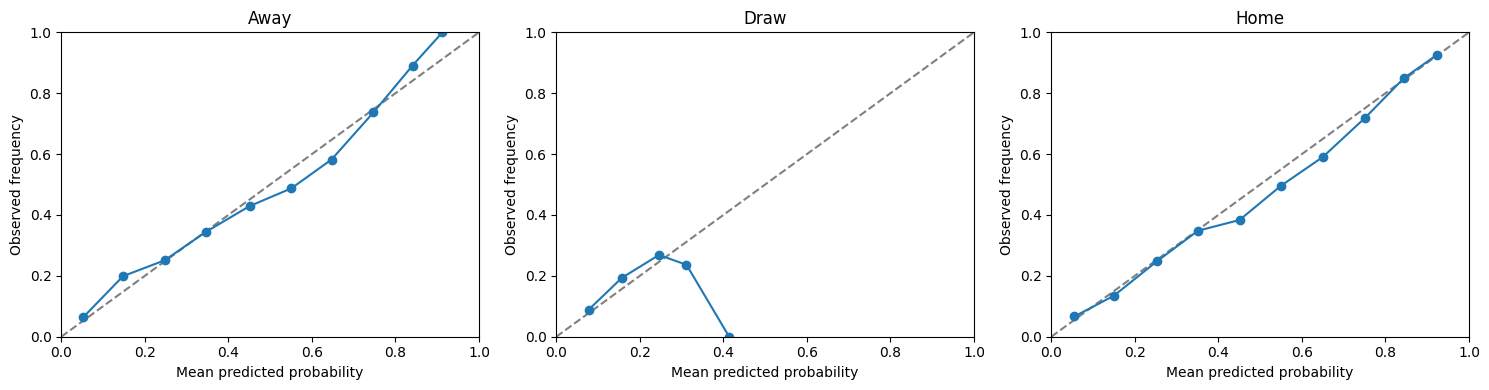

Away


,mean_probability,observed_frequency,matches
bin,,,
"(-0.001, 0.1]",0.053,0.064,905
"(0.1, 0.2]",0.148,0.199,603
"(0.2, 0.3]",0.248,0.251,430
"(0.3, 0.4]",0.346,0.345,325
"(0.4, 0.5]",0.451,0.429,289
"(0.5, 0.6]",0.551,0.488,240
"(0.6, 0.7]",0.647,0.582,225
"(0.7, 0.8]",0.747,0.737,228
"(0.8, 0.9]",0.841,0.891,110


Draw


,mean_probability,observed_frequency,matches
bin,,,
"(-0.001, 0.1]",0.078,0.089,213
"(0.1, 0.2]",0.157,0.194,1487
"(0.2, 0.3]",0.246,0.268,1501
"(0.3, 0.4]",0.312,0.236,165
"(0.4, 0.5]",0.414,0.000,1


Home


,mean_probability,observed_frequency,matches
bin,,,
"(-0.001, 0.1]",0.056,0.067,270
"(0.1, 0.2]",0.150,0.135,349
"(0.2, 0.3]",0.253,0.248,315
"(0.3, 0.4]",0.351,0.348,339
"(0.4, 0.5]",0.451,0.384,365
"(0.5, 0.6]",0.550,0.496,389
"(0.6, 0.7]",0.650,0.590,415
"(0.7, 0.8]",0.751,0.719,470
"(0.8, 0.9]",0.844,0.850,373


In [6]:
# Probability for each outcome, probability reliability, 
# taking predicted probability for each match and grouping them from 
# its probability 20% - 30%
# Calculate the average prediction and compare to the actual
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
reliability_tables = {}

for column, class_id in enumerate(selected_model.classes_):
    class_name = {0: "Away", 1: "Draw", 2: "Home"}[class_id]

    observations = pd.DataFrame({
        "probability": diagnostic_probs[:, column],
        "occurred": (
            diagnostic_data["target"].to_numpy() == class_id
        ).astype(int),
    })

    observations["bin"] = pd.cut(
        observations["probability"],
        bins=np.linspace(0, 1, 11),
        include_lowest=True,
    )

    table = (
        observations.groupby("bin", observed=True)
        .agg(
            mean_probability=("probability", "mean"),
            observed_frequency=("occurred", "mean"),
            matches=("occurred", "size"),
        )
    )

    reliability_tables[class_name] = table

    ax = axes[column]
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.plot(
        table["mean_probability"],
        table["observed_frequency"],
        marker="o",
    )
    ax.set(
        title=class_name,
        xlabel="Mean predicted probability",
        ylabel="Observed frequency",
        xlim=(0, 1),
        ylim=(0, 1),
    )

plt.tight_layout()
plt.show()

for name, table in reliability_tables.items():
    print(name)
    display(table.round(3))

In [1]:
# # obsolete checkpoint
# #  checkpoint, 9/15, saving fitted model ,feature order, reference prob, etc
# from pathlib import Path
# from datetime import datetime, timezone
# import importlib.metadata
# import json
# import joblib
# import pandas as pd

# # A new folder avoids overwriting an earlier checkpoint.
# checkpoint_dir = (
#     Path.cwd()
#     / "checkpoints"
#     / f"v1_{datetime.now().strftime('%Y%m%d_%H%M%S_%f')}"
# )
# checkpoint_dir.mkdir(parents=True, exist_ok=False)

# # Confirm the selected model is still the intended winner.
# assert selected_name == "LR sigmoid"
# assert list(selected_model.classes_) == [0, 1, 2]

# # Save the complete fitted calibrated model, including its LR pipeline.
# bundle = {
#     "version": "v1",
#     "model_name": selected_name,
#     "model": selected_model,
#     "features": list(selected_features),
#     "class_names": {0: "Away", 1: "Draw", 2: "Home"},
#     "target_definition": (
#         "Recorded match outcome including extra time where played; "
#         "excluding penalty shootouts."
#     ),
#     "reference_class_prior": class_prior,
#     "development_end": str(development["date"].max()),
#     "calibration_end": str(calibration["date"].max()),
#     "selection_end": str(selection["date"].max()),
#     "data_cutoff": str(df["date"].max()),
#     "evaluation_note": (
#         "Post-2022 historical holdout was previously inspected."
#     ),
# }

# joblib.dump(bundle, checkpoint_dir / "model_bundle.joblib")

# # Preserve the data and split membership used in this experiment.
# # Pickle preserves pandas types. Load only your own trusted files.
# joblib.dump(
#     {
#         "df": df,
#         "development": development,
#         "calibration": calibration,
#         "selection": selection,
#         "holdout": holdout,
#         "folds": folds,
#     },
#     checkpoint_dir / "experiment_data.joblib",
# )

# # Preserve predictions alongside the exact rows they describe.
# saved_predictions = holdout.copy()
# for column, class_id in enumerate(selected_model.classes_):
#     saved_predictions[f"probability_class_{class_id}"] = (
#         holdout_probs[:, column]
#     )

# saved_predictions.to_csv(
#     checkpoint_dir / "holdout_predictions.csv",
#     index=False,
# )

# # Save available result tables.
# table_names = [
#     "selection_results",
#     "results",
#     "summary",
#     "xgb_combination_results",
#     "tuning_comparison",
#     "yearly_results",
# ]

# for name in table_names:
#     value = globals().get(name)
#     if isinstance(value, pd.DataFrame):
#         value.to_csv(checkpoint_dir / f"{name}.csv", index=False)

# # Preserve original notebook trackers as a convenience snapshot.
# # They are not yet a verified production feature-state artifact.
# tracker_snapshot = {}

# if "elo_tracker" in globals():
#     tracker_snapshot["elo"] = dict(elo_tracker)

# if "goal_tracker" in globals():
#     tracker_snapshot["recent_goals"] = {
#         team: list(goals)
#         for team, goals in goal_tracker.items()
#     }

# joblib.dump(
#     tracker_snapshot,
#     checkpoint_dir / "notebook_trackers.joblib",
# )

# versions = {}
# for package in [
#     "numpy", "pandas", "scikit-learn",
#     "xgboost", "lightgbm", "joblib",
# ]:
#     try:
#         versions[package] = importlib.metadata.version(package)
#     except importlib.metadata.PackageNotFoundError:
#         pass

# metadata = {
#     "saved_at_utc": datetime.now(timezone.utc).isoformat(),
#     "package_versions": versions,
#     "next_steps": [
#         "Verify World Cup rows and retain the recorded-result target.",
#         "Build and verify shared feature construction and cached state.",
#         "Optionally test recency weighting as a separate v2 experiment.",
#     ],
# }

# (checkpoint_dir / "metadata.json").write_text(
#     json.dumps(metadata, indent=2),
#     encoding="utf-8",
# )

# # Verify that the saved model reloads and reproduces predictions.
# restored = joblib.load(checkpoint_dir / "model_bundle.joblib")

# sample = holdout.loc[:, selected_features].astype(float).head(10)

# import numpy as np
# np.testing.assert_allclose(
#     selected_model.predict_proba(sample),
#     restored["model"].predict_proba(sample),
# )

# print("Checkpoint saved and model reload verified:")
# print(checkpoint_dir.resolve())


Saved source checkpoint: v1_1_corrected_20260915_190534_952693


In [ ]:
# Create and update team: predict_match_latest()
# prepares team information when completed results arrive
import math
import numpy as np
import pandas as pd

def new_state():
    return {
        "teams": {},
        "data_cutoff": None,
        "feature_version": "v1",
    }


def new_team_state():
    return {
        "elo": 1500.0,
        "recent_goals": [],
        "last_match_date": None,
    }


# updating elo, recent goals, last-played dates after a match
# -> preparing  data or adding actual results
def update_state(state, match):
    """Update state AFTER a completed competitive match."""

    if match["tournament"] == "Friendly":
        return  # Match the training notebook's filtering.

    if pd.isna(match["home_score"]) or pd.isna(match["away_score"]):
        raise ValueError("Cannot update state with an unplayed match.")

    home = match["home_team"]
    away = match["away_team"]
    date = pd.Timestamp(match["date"])

    if home == away:
        raise ValueError("A team cannot play itself.")

    if (
        state["data_cutoff"] is not None
        and date < pd.Timestamp(state["data_cutoff"])
    ):
        raise ValueError("Process matches in chronological order.")

    home_score = float(match["home_score"])
    away_score = float(match["away_score"])

    if (
        not np.isfinite([home_score, away_score]).all()
        or min(home_score, away_score) < 0
    ):
        raise ValueError("Scores must be finite and nonnegative.")

    for team in [home, away]:
        if team not in state["teams"]:
            state["teams"][team] = new_team_state()

    home_state = state["teams"][home]
    away_state = state["teams"][away]

    home_elo = home_state["elo"]
    away_elo = away_state["elo"]

    if home_score > away_score:
        actual_home = 1.0
    elif home_score < away_score:
        actual_home = 0.0
    else:
        actual_home = 0.5

    # Preserve the ORIGINAL notebook rules for version 1.
    tournament = str(match["tournament"])

    if tournament == "FIFA World Cup":
        k = 60
    elif (
        "World Cup qualification" in tournament
        or "UEFA Euro" in tournament
        or "Copa America" in tournament
    ):
        k = 50
    else:
        k = 40

    margin = abs(home_score - away_score)
    multiplier = math.sqrt(margin) if margin > 0 else 1.0

    expected_home = 1 / (
        1 + 10 ** ((away_elo - home_elo) / 400)
    )

    change = k * multiplier * (actual_home - expected_home)

    home_state["elo"] = home_elo + change
    away_state["elo"] = away_elo - change

    for team_state, goals in [
        (home_state, home_score),
        (away_state, away_score),
    ]:
        team_state["recent_goals"] = (
            team_state["recent_goals"] + [goals]
        )[-5:]

        team_state["last_match_date"] = date.isoformat()

    state["data_cutoff"] = date.isoformat()

In [21]:
# Build the model's inputs: predict_match_latest()
# converts two team's saved information into input columns
def build_match_features(
    state,
    home_team,
    away_team,
    feature_names,
    *,
    is_neutral,
    is_home_team_host,
    allow_unseen=False,
):
    if home_team == away_team:
        raise ValueError("Select two different teams.")

    for value in [is_neutral, is_home_team_host]:
        if not isinstance(value, (bool, np.bool_)):
            raise ValueError("Venue flags must be booleans.")

    if is_neutral and is_home_team_host:
        raise ValueError("A neutral match cannot have home-host=True.")

    expected_features = {
        "elo_difference",
        "is_home_team_host",
        "neutral",
        "form_difference",
        "abs_elo_difference",
    }

    if (
        set(feature_names) != expected_features
        or len(feature_names) != len(expected_features)
    ):
        raise ValueError("Unexpected version 1 feature schema.")

    def get_team(team):
        if team in state["teams"]:
            return state["teams"][team]

        # Needed to reproduce training features for first appearances.
        if allow_unseen:
            return new_team_state()

        raise ValueError(f"No recorded competitive history for {team!r}.")

    home = get_team(home_team)
    away = get_team(away_team)

    def mean_goals(team):
        goals = team["recent_goals"]
        return float(np.mean(goals)) if goals else 0.0

    elo_difference = home["elo"] - away["elo"]

    values = {
        "elo_difference": elo_difference,
        "is_home_team_host": float(is_home_team_host),
        "neutral": float(is_neutral),
        "form_difference": mean_goals(home) - mean_goals(away),
        "abs_elo_difference": abs(elo_difference),
    }

    return pd.DataFrame(
        [values],
        columns=list(feature_names),
    ).astype(float)

In [ ]:
# Verify against saved training features, checking that same feature is generated (next 
from pathlib import Path
import joblib

history = df.copy(deep=True)
history["date"] = pd.to_datetime(history["date"])

history = (
    history.loc[history["tournament"].ne("Friendly")]
    .dropna(subset=["home_score", "away_score"])
    .sort_values("date", kind="stable")
    .copy()
)

history["abs_elo_difference"] = history["elo_difference"].abs()

assert history["date"].is_monotonic_increasing

print("Checking freshly generated features:", len(history))

history = (
    history.loc[history["tournament"].ne("Friendly")]
    .dropna(subset=["home_score", "away_score"])
    .copy()
)

history["date"] = pd.to_datetime(history["date"])



Checking freshly generated features: 31089


In [23]:
# Reconstructing the features, (next couple cells: correctness of order fix and
# reproducibility check = old checkpoint had saved row order differ from order
# used to calculate Elo, thus not reproducilbe or constant <- use first
# checkpoint as reference, the saved table could produce different elo values)
# .sort_value used without stable, old checkpoint trained model from that 
state = new_state()
checked = 0

# This feature can be reconstructed directly if absent from saved df.
if "abs_elo_difference" not in history.columns:
    history["abs_elo_difference"] = history["elo_difference"].abs()

for match in history.to_dict("records"):
    generated = build_match_features(
        state,
        match["home_team"],
        match["away_team"],
        selected_features,
        is_neutral=match["neutral"],
        is_home_team_host=match["is_home_team_host"],
        allow_unseen=True,
    )

    expected = np.array(
        [match[column] for column in selected_features],
        dtype=float,
    )

    np.testing.assert_allclose(
        generated.iloc[0].to_numpy(),
        expected,
        rtol=1e-9,
        atol=1e-8,
        err_msg=(
            f"Feature mismatch: {match['date']} "
            f"{match['home_team']} vs {match['away_team']}"
        ),
    )

    # Only now may this match influence future features.
    update_state(state, match)
    checked += 1

print(f"Feature consistency verified for {checked} matches.")

Feature consistency verified for 31089 matches.


### Local checkpoint required — Historical diagnostics

This section loads:
`checkpoints/v1_20260915_113112_401128`

That folder is excluded from the public repository. The saved outputs
are retained as part of the research record.

Skip this section and its dependent diagnostic cells when running
without the local checkpoint. It is not needed for the Flask app.

In [ ]:
# Recovering the selected LR configuration
from pathlib import Path
from datetime import datetime, timezone
import json
import platform

import joblib
import numpy as np
import pandas as pd
import sklearn

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import log_loss, accuracy_score

source_checkpoint = Path(
    PROJECT_ROOT / "checkpoints" / "v1_20260915_113112_401128"
)

old_bundle = joblib.load(
    source_checkpoint / "model_bundle.joblib"
)

assert old_bundle["model_name"] == "LR sigmoid"

# The saved calibrator wraps a FrozenEstimator containing the LR pipeline.
old_calibrated_model = old_bundle["model"]
frozen_estimator = old_calibrated_model.estimator

if not isinstance(frozen_estimator, FrozenEstimator):
    raise TypeError(
        "Expected the saved model to wrap a FrozenEstimator. "
        "Check that you loaded the correct LR sigmoid checkpoint."
    )

# Clone the underlying pipeline, not the FrozenEstimator.
# This preserves settings but discards learned coefficients/scaling.
corrected_lr = clone(frozen_estimator.estimator)

selected_features = list(old_bundle["features"])

print("Features:", selected_features)
print("LR settings:", corrected_lr.named_steps["model"].get_params())

Features: ['elo_difference', 'is_home_team_host', 'neutral', 'form_difference', 'abs_elo_difference']
LR settings: {'C': 0.01, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 3000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [155]:
# Rebuilding the partitions (development, calibration, selection, holdout)
corrected_df = df.copy(deep=True)
corrected_df["date"] = pd.to_datetime(corrected_df["date"])

corrected_df = (
    corrected_df.loc[corrected_df["tournament"].ne("Friendly")]
    .dropna(subset=["home_score", "away_score"])
    .sort_values("date", kind="stable")
    .reset_index(drop=True)
)

corrected_df["abs_elo_difference"] = (
    corrected_df["elo_difference"].abs()
)

corrected_df["target"] = np.select(
    [
        corrected_df["home_score"] < corrected_df["away_score"],
        corrected_df["home_score"] > corrected_df["away_score"],
    ],
    [0, 2],
    default=1,
).astype(int)

development = corrected_df.loc[
    corrected_df["date"] < "2018-01-01"
].copy()

calibration = corrected_df.loc[
    (corrected_df["date"] >= "2018-01-01")
    & (corrected_df["date"] < "2020-01-01")
].copy()

selection = corrected_df.loc[
    (corrected_df["date"] >= "2020-01-01")
    & (corrected_df["date"] < "2022-01-01")
].copy()

holdout = corrected_df.loc[
    corrected_df["date"] >= "2022-01-01"
].copy()

partitions = {
    "development": development,
    "calibration": calibration,
    "selection": selection,
    "holdout": holdout,
}

for name, part in partitions.items():
    assert not part.empty, f"{name} is empty"
    assert np.isfinite(
        part[selected_features].to_numpy(dtype=float)
    ).all(), f"Invalid features in {name}"

for earlier, later in zip(
    list(partitions.values())[:-1],
    list(partitions.values())[1:],
):
    assert earlier["date"].max() < later["date"].min()

display(pd.DataFrame([
    {
        "partition": name,
        "matches": len(part),
        "start": part["date"].min().date(),
        "end": part["date"].max().date(),
    }
    for name, part in partitions.items()
]))

,partition,matches,start,end
0,development,25181,1884-01-26,2017-12-29
1,calibration,1398,2018-01-02,2019-12-18
2,selection,1143,2020-09-03,2021-12-29
3,holdout,3367,2022-01-01,2026-06-27


In [156]:
# Refitting LR, then fitting its calibration layer
corrected_lr.fit(
    development[selected_features].astype(float),
    development["target"],
)

selected_model = CalibratedClassifierCV(
    estimator=FrozenEstimator(corrected_lr),
    method="sigmoid",
)

selected_model.fit(
    calibration[selected_features].astype(float),
    calibration["target"],
)

selected_name = "LR sigmoid"

assert np.array_equal(selected_model.classes_, [0, 1, 2])

print("Corrected LR and sigmoid calibration fitted.")

Corrected LR and sigmoid calibration fitted.


In [157]:
# Reevaluate the fixed configuration
class_prior = (
    development["target"]
    .value_counts(normalize=True)
    .reindex([0, 1, 2], fill_value=0)
    .to_numpy()
)

assert (class_prior > 0).all()

evaluation_rows = []
prediction_tables = {}

for name in ["selection", "holdout"]:
    part = partitions[name]

    probabilities = selected_model.predict_proba(
        part[selected_features].astype(float)
    )

    assert np.isfinite(probabilities).all()
    assert np.allclose(probabilities.sum(axis=1), 1.0)

    reference_probs = np.tile(class_prior, (len(part), 1))

    model_loss = log_loss(
        part["target"], probabilities, labels=[0, 1, 2]
    )
    reference_loss = log_loss(
        part["target"], reference_probs, labels=[0, 1, 2]
    )

    evaluation_rows.append({
        "partition": name,
        "matches": len(part),
        "model_log_loss": model_loss,
        "reference_log_loss": reference_loss,
        "improvement": reference_loss - model_loss,
        "accuracy": accuracy_score(
            part["target"],
            selected_model.classes_[probabilities.argmax(axis=1)],
        ),
    })

    saved = part.copy()
    for column, class_id in enumerate(selected_model.classes_):
        saved[f"probability_class_{class_id}"] = probabilities[:, column]

    prediction_tables[name] = saved

    if name == "holdout":
        holdout_probs = probabilities

evaluation_results = pd.DataFrame(evaluation_rows)
display(evaluation_results.round(6))

,partition,matches,model_log_loss,reference_log_loss,improvement,accuracy
0,selection,1143,0.834752,1.062585,0.227833,0.624672
1,holdout,3367,0.886572,1.056874,0.170302,0.602614


### Local checkpoint required — Historical diagnostics

This section loads:
`checkpoints/v1_1_corrected_20260915_190534_952693/model_bundle.joblib`

That folder is excluded from the public repository. The saved outputs
are retained as part of the research record.

Skip this section and its dependent diagnostic cells when running
without the local checkpoint. It is not needed for the Flask app.

In [ ]:
# Saving corrected version to the notebook
checkpoint_dir = (
    source_checkpoint.parent
    / f"v1_1_corrected_{datetime.now().strftime('%Y%m%d_%H%M%S_%f')}"
)
checkpoint_dir.mkdir(parents=True, exist_ok=False)

bundle = {
    "version": "v1.1",
    "feature_version": "v1.1_stable_order",
    "model_name": selected_name,
    "model": selected_model,
    "features": selected_features,
    "class_names": {0: "Away", 1: "Draw", 2: "Home"},
    "target_definition": old_bundle["target_definition"],
    "reference_class_prior": class_prior,
    "development_end": str(development["date"].max()),
    "calibration_end": str(calibration["date"].max()),
    "selection_end": str(selection["date"].max()),
    "data_cutoff": str(corrected_df["date"].max()),
    "source_checkpoint": source_checkpoint.name,
    "evaluation_note": (
        "Correctness refit after stabilizing same-date row order. "
        "Reuses previously selected LR settings and sigmoid method. "
        "Selection and holdout periods have already been inspected."
    ),
}

joblib.dump(bundle, checkpoint_dir / "model_bundle.joblib")

# Rebuild fold indices for the corrected development dataframe.
folds = make_date_folds(development)

joblib.dump(
    {
        "df": corrected_df,
        **partitions,
        "folds": folds,
    },
    checkpoint_dir / "experiment_data.joblib",
)

evaluation_results.to_csv(
    checkpoint_dir / "evaluation_results.csv",
    index=False,
)

for name, table in prediction_tables.items():
    table.to_csv(
        checkpoint_dir / f"{name}_predictions.csv",
        index=False,
    )

metadata = {
    "saved_at_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(),
    "scikit-learn": sklearn.__version__,
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "joblib": joblib.__version__,
}

(checkpoint_dir / "metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

# Verify the saved artifact reproduces predictions.
restored = joblib.load(checkpoint_dir / "model_bundle.joblib")
sample = holdout[selected_features].astype(float).head(10)

np.testing.assert_allclose(
    selected_model.predict_proba(sample),
    restored["model"].predict_proba(sample),
)

# Keep notebook data aligned with the corrected model.
df = corrected_df.copy()

print("Corrected checkpoint saved and reload verified:")
print(checkpoint_dir.name)

### Local checkpoint required — Historical diagnostics

This section loads:
`checkpoints/v1_1_corrected_20260915_190534_952693/model_bundle.joblib`
`checkpoints/v1_1_corrected_20260915_190534_952693/experiment_data.joblib`


That folder is excluded from the public repository. The saved outputs
are retained as part of the research record.

Skip this section and its dependent diagnostic cells when running
without the local checkpoint. It is not needed for the Flask app.

In [ ]:
# Build and verify the snapshot using checkpoint's data, team state, etc
from pathlib import Path
import joblib
import numpy as np
import pandas as pd

checkpoint_dir = Path(checkpoint_dir)

bundle = joblib.load(checkpoint_dir / "model_bundle.joblib")
experiment = joblib.load(checkpoint_dir / "experiment_data.joblib")

feature_names = list(bundle["features"])

history = (
    experiment["df"]
    .sort_values("date", kind="stable")
    .copy()
)

state = new_state()
state["feature_version"] = bundle["feature_version"]
checked = 0

for match in history.to_dict("records"):
    # Reconstruct each match's features before recording its result.
    generated = build_match_features(
        state,
        match["home_team"],
        match["away_team"],
        feature_names,
        is_neutral=match["neutral"],
        is_home_team_host=match["is_home_team_host"],
        allow_unseen=True,
    )

    expected = np.array(
        [match[column] for column in feature_names],
        dtype=float,
    )

    np.testing.assert_allclose(
        generated.iloc[0].to_numpy(),
        expected,
        rtol=1e-9,
        atol=1e-8,
        err_msg=(
            f"Feature mismatch: {match['date']} "
            f"{match['home_team']} vs {match['away_team']}"
        ),
    )

    update_state(state, match)
    checked += 1

state["matches_processed"] = checked
state["checkpoint_id"] = checkpoint_dir.name

joblib.dump(
    state,
    checkpoint_dir / "latest_team_state.joblib",
)

print(f"Verified and saved state from {checked} matches.")
print("Data cutoff:", state["data_cutoff"])

Verified and saved state from 31089 matches.
Data cutoff: 2026-06-27T00:00:00


In [ ]:
# Implementing predict_match_latest(), predicting the results based on the
# team's latest features as prepared from update_state() using specified 
# experiment data
def predict_match_latest(
    home_team,
    away_team,
    *,
    is_neutral=True,
    is_home_team_host=None,
):
    """Predict using the loaded model and latest saved team state."""

    if not isinstance(home_team, str) or not isinstance(away_team, str):
        raise ValueError("Team names must be strings.")

    home_team = home_team.strip()
    away_team = away_team.strip()

    if not home_team or not away_team:
        raise ValueError("Provide both team names.")

    if not isinstance(is_neutral, (bool, np.bool_)):
        raise ValueError("is_neutral must be True or False.")

    if is_home_team_host is None:
        if is_neutral:
            is_home_team_host = False
        else:
            raise ValueError(
                "For a non-neutral match, specify whether "
                "the first-listed team is actually the host."
            )

    model = prediction_bundle["model"]

    features = build_match_features(
        prediction_state,
        home_team,
        away_team,
        prediction_bundle["features"],
        is_neutral=is_neutral,
        is_home_team_host=is_home_team_host,
        allow_unseen=False,
    )

    probabilities = model.predict_proba(features)[0]

    if (
        not np.isfinite(probabilities).all()
        or (probabilities < 0).any()
        or not np.isclose(probabilities.sum(), 1.0)
    ):
        raise ValueError("Invalid model probabilities.")

    by_class = dict(zip(model.classes_, probabilities))

    return {
        "home_team": home_team,
        "away_team": away_team,
        "probabilities": {
            "home_win": float(by_class[2]),
            "draw": float(by_class[1]),
            "away_win": float(by_class[0]),
        },
        "is_neutral": bool(is_neutral),
        "is_home_team_host": bool(is_home_team_host),
        "target_definition": prediction_bundle["target_definition"],
        "model_version": prediction_bundle["version"],
        "model_training_end": prediction_bundle["development_end"],
        "model_calibration_end": prediction_bundle["calibration_end"],
        "results_available_through": prediction_state["data_cutoff"],
    }




Japan win:     45.0%
Draw:          23.0%
Australia win: 32.1%
Results available through: 2026-06-27T00:00:00
Outcome definition: Recorded match outcome including extra time where played; excluding penalty shootouts.


### Local checkpoint required — Historical diagnostics

This section loads:
`checkpoints/v1_1_corrected_20260915_190534_952693/`
`checkpoints/v1_1_corrected_20260915_190534_952693/model_bundle.joblib`
`checkpoints/v1_1_corrected_20260915_190534_952693/experiment_data.joblib`
`checkpoints/v1_1_corrected_20260915_190534_952693/latest_team_state.joblib`

That folder is excluded from the public repository. The saved outputs
are retained as part of the research record.

Skip this section and its dependent diagnostic cells when running
without the local checkpoint. It is not needed for the Flask app.

In [ ]:
# Creating a separate deployment fit (deployment artifacts: Model being 
# fitted on a more recent deployment data, deployment partition 
# more recent fit with separate calibration data
from pathlib import Path
from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

source_checkpoint = (
    CHECKPOINT_ROOT / "v1_1_corrected_20260915_190534_952693"
)
source_dir = source_checkpoint

historical_bundle = joblib.load(
    source_dir / "model_bundle.joblib"
)
historical_experiment = joblib.load(
    source_dir / "experiment_data.joblib"
)
latest_state = joblib.load(
    source_dir / "latest_team_state.joblib"
)

deployment_data = (
    historical_experiment["df"]
    .copy()
    .sort_values("date", kind="stable")
)

deployment_data["date"] = pd.to_datetime(deployment_data["date"])

feature_names = list(historical_bundle["features"])

assert (
    latest_state["feature_version"]
    == historical_bundle["feature_version"]
)

# Exclusive end boundary includes all matches on the latest date.
data_cutoff = deployment_data["date"].max().normalize()
calibration_end = data_cutoff + pd.Timedelta(days=1)
calibration_start = calibration_end - pd.DateOffset(years=2)

deployment_train = deployment_data.loc[
    deployment_data["date"] < calibration_start
].copy()

deployment_calibration = deployment_data.loc[
    (deployment_data["date"] >= calibration_start)
    & (deployment_data["date"] < calibration_end)
].copy()

assert not deployment_train.empty
assert not deployment_calibration.empty
assert (
    deployment_train["date"].max()
    < deployment_calibration["date"].min()
)

assert (
    pd.Timestamp(latest_state["data_cutoff"]).normalize()
    == data_cutoff
)

for part in [deployment_train, deployment_calibration]:
    assert set(part["target"].unique()) == {0, 1, 2}
    assert np.isfinite(
        part[feature_names].to_numpy(dtype=float)
    ).all()

display(pd.DataFrame([
    {
        "partition": name,
        "matches": len(part),
        "start": part["date"].min(),
        "end": part["date"].max(),
    }
    for name, part in [
        ("deployment_train", deployment_train),
        ("deployment_calibration", deployment_calibration),
    ]
]))

,partition,matches,start,end
0,deployment_train,29523,1884-01-26,2024-06-27
1,deployment_calibration,1566,2024-06-28,2026-06-27


In [11]:
# Fitting deployment model with LR configuration
historical_calibrator = historical_bundle["model"]

assert isinstance(
    historical_calibrator.estimator,
    FrozenEstimator,
)

# Clone the underlying pipeline, not its frozen wrapper.
deployment_lr = clone(
    historical_calibrator.estimator.estimator
)

deployment_lr.fit(
    deployment_train[feature_names].astype(float),
    deployment_train["target"],
)

deployment_model = CalibratedClassifierCV(
    estimator=FrozenEstimator(deployment_lr),
    method="sigmoid",
)

deployment_model.fit(
    deployment_calibration[feature_names].astype(float),
    deployment_calibration["target"],
)

print("Deployment model fitted.")

Deployment model fitted.


### Local checkpoint required — Historical diagnostics

This section loads:
`checkpoints/v1_1_corrected_20260915_190534_952693/model_bundle.joblib`

That folder is excluded from the public repository. The saved outputs
are retained as part of the research record.

Skip this section and its dependent diagnostic cells when running
without the local checkpoint. It is not needed for the Flask app.

In [ ]:
# Saving the model
deployment_dir = (
    source_dir.parent
    / f"deployment_v1_1_{datetime.now().strftime('%Y%m%d_%H%M%S_%f')}"
)
deployment_dir.mkdir(parents=True, exist_ok=False)

deployment_bundle = {
    "version": "v1.1-deployment",
    "feature_version": historical_bundle["feature_version"],
    "model_name": "LR sigmoid",
    "model": deployment_model,
    "features": feature_names,
    "class_names": historical_bundle["class_names"],
    "target_definition": historical_bundle["target_definition"],
    "development_end": str(deployment_train["date"].max()),
    "calibration_end": str(deployment_calibration["date"].max()),
    "data_cutoff": str(data_cutoff),
    "calibration_window_start": str(calibration_start),
    "source_checkpoint": source_dir.name,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "evaluation_note": (
        "Deployment refit using newer data, including previously "
        "evaluated periods. Historical benchmark scores do not "
        "constitute an independent evaluation of this fitted artifact."
    ),
}

# Same verified feature rules and history; no state rebuild is needed.
deployment_state = dict(latest_state)
deployment_state["checkpoint_id"] = deployment_dir.name

joblib.dump(
    deployment_bundle,
    deployment_dir / "model_bundle.joblib",
)
joblib.dump(
    deployment_state,
    deployment_dir / "latest_team_state.joblib",
)

# Verify serialization, not predictive performance.
reloaded = joblib.load(deployment_dir / "model_bundle.joblib")
sample = deployment_calibration[feature_names].astype(float).head(10)

np.testing.assert_allclose(
    deployment_model.predict_proba(sample),
    reloaded["model"].predict_proba(sample),
)

print("Deployment artifacts saved and reload verified:")
print(deployment_dir.name)

### Local checkpoint required — Historical diagnostics

This section loads:
`checkpoints/v1_1_corrected_20260915_190534_952693/model_bundle.joblib`
`checkpoints/v1_1_corrected_20260915_190534_952693/latest_team_state.joblib`

That folder is excluded from the public repository. The saved outputs
are retained as part of the research record.

Skip this section and its dependent diagnostic cells when running
without the local checkpoint. It is not needed for the Flask app.

In [26]:
# Utilizing prediciton function on the deployment model
prediction_bundle = joblib.load(
    deployment_dir / "model_bundle.joblib"
)
prediction_state = joblib.load(
    deployment_dir / "latest_team_state.joblib"
)

assert (
    prediction_bundle["feature_version"]
    == prediction_state["feature_version"]
)

prediction = predict_match_latest(
    "Japan",
    "Australia",
    is_neutral=True,
)

print(prediction)

{'home_team': 'Japan', 'away_team': 'Australia', 'probabilities': {'home_win': 0.4497600495376892, 'draw': 0.2295075814884537, 'away_win': 0.3207323689738571}, 'is_neutral': True, 'is_home_team_host': False, 'target_definition': 'Recorded match outcome including extra time where played; excluding penalty shootouts.', 'model_version': 'v1.1-deployment', 'model_training_end': '2024-06-27 00:00:00', 'model_calibration_end': '2026-06-27 00:00:00', 'results_available_through': '2026-06-27T00:00:00'}


In [ ]:
# testing predict_match_latest() 
prediction = predict_match_latest(
    "Japan",
    "Australia",
    is_neutral=True,
)

p = prediction["probabilities"]

print(f"Japan win:     {p['home_win']:.1%}")
print(f"Draw:          {p['draw']:.1%}")
print(f"Australia win: {p['away_win']:.1%}")
print("Results available through:", prediction["results_available_through"])
print("Outcome definition:", prediction["target_definition"])

In [ ]:
# Checking that predictions do not change the saved state (checkpoints)
import copy

state_before = copy.deepcopy(prediction_state)

first = predict_match_latest("Japan", "Australia")
second = predict_match_latest("Japan", "Australia")

assert prediction_state == state_before
assert first["probabilities"] == second["probabilities"]
assert np.isclose(sum(first["probabilities"].values()), 1.0)

for home, away in [
    ("Japan", "Japan"),
    ("Unknown Team", "Australia"),
]:
    try:
        predict_match_latest(home, away)
    except ValueError:
        pass
    else:
        raise AssertionError(f"Expected rejection: {home} vs {away}")

print("Prediction checks passed.")

In [ ]:
from pathlib import Path
import joblib
model = PROJECT_ROOT / "checkpoints"
checkpoint_root = Path(
    model
)

for folder in sorted(checkpoint_root.iterdir()):
    if folder.is_dir():
        print(folder.name)

v1_1_corrected_20260915_190534_952693
v1_1_corrected_20260917_084522_967731
v1_20260915_113112_401128
v1_20260915_173148_554858
v1_20260915_174526_648910
v1_20260915_180411_083459


### Local checkpoint required — Historical diagnostics

This section loads:
`checkpoints/v1_1_corrected_20260915_190534_952693/model_bundle.joblib`

That folder is excluded from the public repository. The saved outputs
are retained as part of the research record.

Skip this section and its dependent diagnostic cells when running
without the local checkpoint. It is not needed for the Flask app.

In [ ]:
checkpoint_dir = checkpoint_root / "v1_1_corrected_20260915_190534_952693"

assert (checkpoint_dir / "model_bundle.joblib").is_file()
assert (checkpoint_dir / "experiment_data.joblib").is_file()
assert (checkpoint_dir / "latest_team_state.joblib").is_file()

bundle = joblib.load(checkpoint_dir / "model_bundle.joblib")

selected_model = bundle["model"]
selected_features = list(bundle["features"])
selected_name = bundle["model_name"]

print("Using:", checkpoint_dir.name)
print("Model version:", bundle["version"])
print("Feature version:", bundle["feature_version"])

In [ ]:
# 1 Compare XGBoost with H2H, H2H + scoring level, and H2H + scoring level + rest on development folds	Which feature set is most useful?
# 2	Tune the strongest XGBoost configuration and LR + strength gap on those same development folds	What settings work best?
# 3	Fit each finalist on all development data	Produce the two fitted base models.
# 4	Fit a sigmoid calibrator for each using only the calibration period	Produce calibrated alternatives.
# 5	Compare the four candidates on the selection period	Choose XGBoost/LR and raw/calibrated probabilities.
# 6	Freeze that choice and evaluate on the historical holdout	Report its later-period performance

# Finish evaluation: holdout loss, yearly results, classwise calibration, and neutral-match performance.
# Build shared prediction logic: the same pre-match feature calculations for backtesting and the app.
# Prepare a deployment model: after recording evaluation, refit under a documented chronological training/calibration policy using more recent data. Preserve the evaluated model separately.
# Build the matchup UI: team selectors, venue, probabilities, and the data cutoff date.

# development experiemnt and tuning -> calibration -> selecting model -> evaluation
# -> frozen-model diagnostics -> confirm outcome definition -> implement/test predict_match
# perpare a separate deployment fit -> flask UI